# Telco Customer Churn Prediction ML Project
**Author:** Jeongwoo Kim  
**Date:** 2025-10-26  

## Project Overview
In the telecom industry, customer churn, when users stop using the service, can significantly affect a company’s revenue and growth.
Retaining existing customers is much more cost effective than acquiring new ones, but identifying which customers are likely to leave remains a major challenge.

The goal of this project is to analyze customer data to understand the key factors that influence churn and to develop a model that can predict whether a customer will stay or leave based on their characteristics such as contract type, service usage, and monthly charges.

By identifying these patterns, businesses can take proactive steps to improve customer retention and long term profitability.

## Install Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve

## Dataset Overview

**Dataset**: `WA_Fn-UseC_-Telco-Customer-Churn.csv`

**Source**: [Kaggle - Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) 

**Size**: 7,043 rows × 21 columns

**Target**: `Churn` — Yes (customer left), No (customer stayed)  

**Note**: The dataset includes both categorical and numerical variables such as gender, tenure, monthly charges, and contract type. 

In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\n Columns:", list(df.columns))

display(df.head())

print("\n Data types and missing values:")
display(df.isnull().sum().to_frame("Missing Values").join(df.dtypes.to_frame("Type")))

print("\n Summary statistics:")
display(df.describe().T)



Shape: (7043, 21)

 Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



 Data types and missing values:


,Missing Values,Type
customerID,0,object
gender,0,object
SeniorCitizen,0,int64
Partner,0,object
Dependents,0,object
tenure,0,int64
PhoneService,0,object
MultipleLines,0,object
InternetService,0,object
OnlineSecurity,0,object



 Summary statistics:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


## Features Engineering
In this step, I removed unnecessary columns and prepared the data for modeling. 

The customerID column was dropped because it is only an identifier and not useful for prediction. The TotalCharges column was also removed since its information overlaps with tenure and MonthlyCharges. In addition, six Internet-related (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, and StreamingMovies) columns were excluded because they are sub-features of InternetService and could introduce redundancy in the dataset.

Additionally, I converted categorical columns into numeric format to simplify model training.

In [3]:
# Drop Columns

drop_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'customerID', 'TotalCharges']
df = df.drop(columns=drop_cols)


In [4]:
# Convert binary categorical features to numeric values
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# Convert Contract features to numeric values
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_map)

# Convert PaymentMethod to numeric values
payment_map = {'Electronic check': 0, 'Mailed check': 1, 'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3}
df['PaymentMethod'] = df['PaymentMethod'].map(payment_map)

# Convert MultipleLines features to numeric values
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0})

# Convert InternetService features to numeric values
internet_map = {'DSL': 0, 'Fiber optic': 1, 'No': 2}
df['InternetService'] = df['InternetService'].map(internet_map)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   Contract          7043 non-null   int64  
 9   PaperlessBilling  7043 non-null   int64  
 10  PaymentMethod     7043 non-null   int64  
 11  MonthlyCharges    7043 non-null   float64
 12  Churn             7043 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 715.4 KB



## EDA & Data Visualization

All feature distributions were visualized to understand the overall shape and characteristics of the dataset.

Most categorical variables were successfully converted into binary or numeric form, and continuous features such as tenure and MonthlyCharges showed slightly skewed distributions.

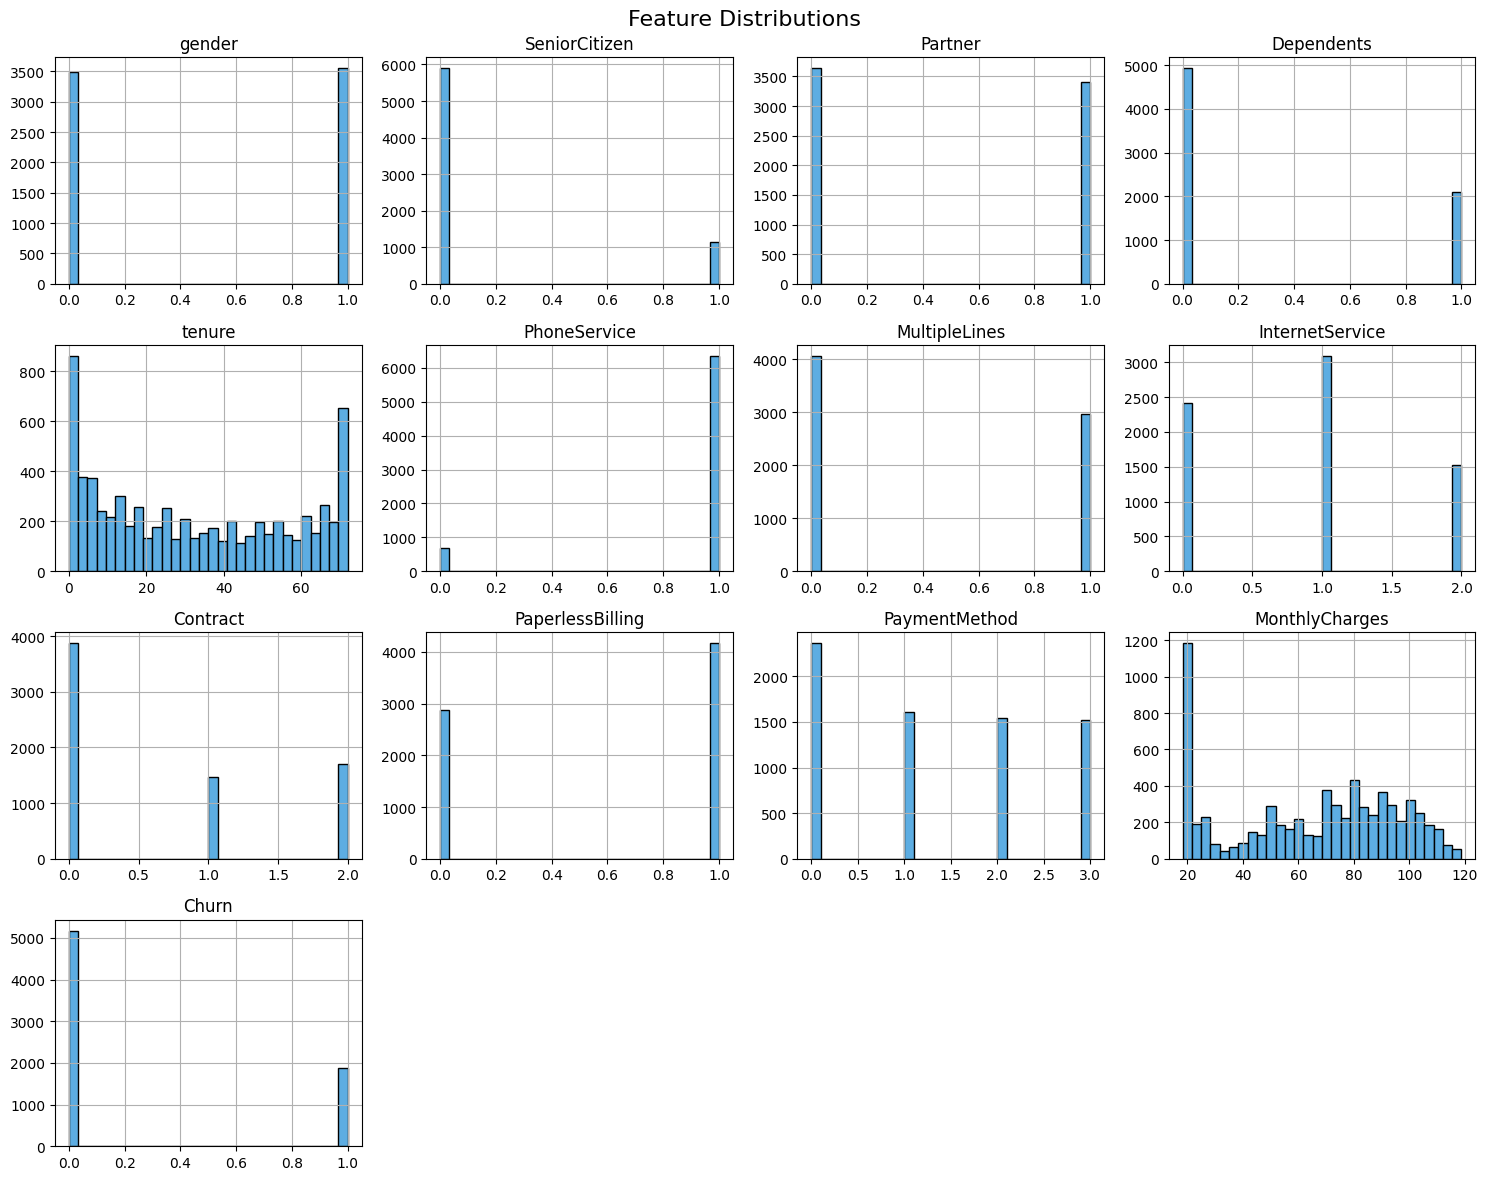

In [5]:
# All features distribution Visualization
import matplotlib.pyplot as plt

df.hist(figsize=(15, 12), bins=30, edgecolor='black', color='#5DADE2')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


## Problem Definition and Model Selection

The main goal of this project is to predict whether a customer will leave or stay with the company based on their personal and service information.

I used two simple but effective classification models: K-Nearest Neighbors (KNN) and Naive Bayes. KNN makes predictions by looking at similar customers and how they behaved, while Naive Bayes uses probabilities to estimate the likelihood of churn.

By comparing these two models, I aimed to see which approach performs better for predicting customer churn. This comparison helps highlight the strengths and limitations of both distance-based and probability-based methods.


## Modeling - Naive Bayes

Train size: (4930, 12)
Test size: (2113, 12)
Train Accuracy: 0.759
Test Accuracy:  0.740


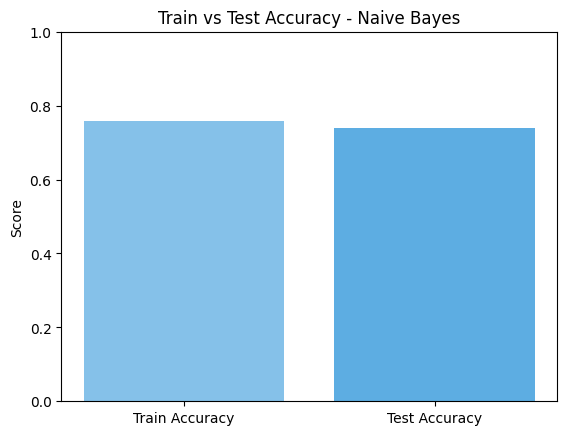

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Train/Test Split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Predict on both Train and Test using Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_train_pred = nb_model.predict(X_train)
y_test_pred = nb_model.predict(X_test)

# Accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy:  {test_accuracy:.3f}")

# Visualize Accuracy
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_accuracy, test_accuracy], color=['#85C1E9', '#5DADE2'])
plt.title('Train vs Test Accuracy - Naive Bayes')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.show()


## Model Evaluation - Naive Bayes

The Naive Bayes model achieved a training accuracy of 75.9% and a testing accuracy of 74.0%, indicating consistent performance between training and unseen data.

This suggests that the model generalizes well without severe overfitting.

From the perspective of the bias and variance tradeoff, Naive Bayes can be seen as a high bias and low variance model. Its simplicity limits flexibility but ensures stable and reliable performance across different datasets.

## Modeling - K-Nearest Neighbors

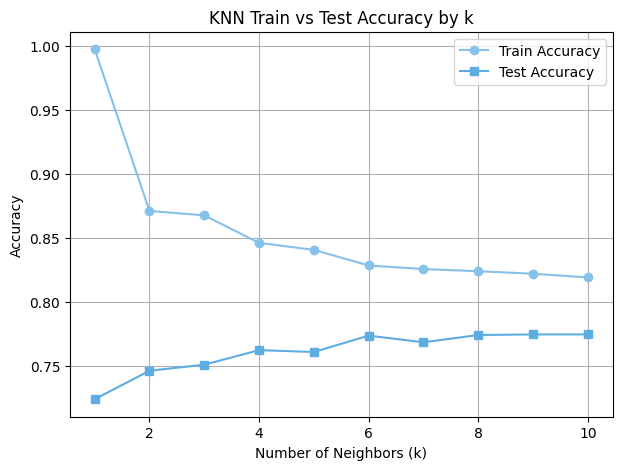

Best k = 9
Train Accuracy: 0.822
Test Accuracy:  0.775


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Train/Test split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Try multiple k values and evaluate performance (on Test set)
k_values = range(1, 11)
test_accuracy_scores = []
train_accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    # Accuracy for both sets
    train_accuracy_scores.append(accuracy_score(y_train, y_train_pred))
    test_accuracy_scores.append(accuracy_score(y_test, y_test_pred))

# Visualization
plt.figure(figsize=(7,5))
plt.plot(k_values, train_accuracy_scores, marker='o', color='#85C1E9', label='Train Accuracy')
plt.plot(k_values, test_accuracy_scores, marker='s', color='#5DADE2', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Train vs Test Accuracy by k')
plt.legend()
plt.grid(True)
plt.show()

# Select best k
best_k = k_values[test_accuracy_scores.index(max(test_accuracy_scores))]
print(f"Best k = {best_k}")

# Evaluate final model
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# Final Accuracy
train_pred = best_knn.predict(X_train)
test_pred = best_knn.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy:  {test_acc:.3f}")




## Model Evaluation – K-Nearest Neighbors

The KNN model achieved a training accuracy of 82.2% and a testing accuracy of 77.5% with k = 9.

The small gap between training and testing accuracy indicates that the model performs consistently without serious overfitting.

This suggests that KNN captures useful patterns from the data while maintaining good generalization to unseen samples.

From the perspective of the bias and variance tradeoff, KNN with k = 9 shows a balanced behavior, avoiding both high bias from oversimplification and high variance from excessive complexity.

## Model Comparison and Conclusion

Between the two models, K Nearest Neighbors KNN and Naive Bayes, both performed reasonably well in predicting customer churn. Naive Bayes achieved slightly lower accuracy (74.0%) but showed very stable performance across training and testing data, indicating high bias and low variance. In contrast, KNN achieved higher overall accuracy (77.5%) and captured more complex relationships, though it showed a slightly higher variance due to its flexibility.

Overall, KNN demonstrated better predictive power for this dataset, while Naive Bayes provided more consistent generalization. Considering the tradeoff between bias and variance, KNN with k = 9 represents a balanced and effective model choice for churn prediction in this project.